## Assignment 5 - Application of clustering algorithms and evaluating performance

#### Preparing the data

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df_wdbc = pd.read_csv("./wdbc.data", header=None)

# Unlabel the dataset
df_wdbc_unlabeled = df_wdbc.drop(columns=[0,1])

# Apply column names to each feature in the dataset
df_wdbc_unlabeled.columns = ['Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1', 'Compactness1', 'Concavity1', 'Concave points1', 'Symmetry1', 'Fractal dimension1',
                    'Radius2', 'Texture2', 'Perimeter2', 'Area2', 'Smoothness2', 'Compactness2', 'Concavity2', 'Concave points2', 'Symmetry2', 'Fractal dimension2',
                    'Radius3', 'Texture3', 'Perimeter3', 'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'Concave points3', 'Symmetry3', 'Fractal dimension3'
]

df_wdbc_unlabeled



,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,Concave points1,Symmetry1,Fractal dimension1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,Concave points3,Symmetry3,Fractal dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_wdbc_unlabeled)

# True labels (column 1: M=malignant, B=benign)
true_labels = df_wdbc[1].map({'M': 1, 'B': 0}).values

# Cluster range
k_range = range(2, 11)

# Storage for scores
kmeans_sil, kmeans_ari = [], []
hier_sil, hier_ari = [], []

for k in k_range:
    # K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    kmeans_sil.append(silhouette_score(X_scaled, km_labels))
    kmeans_ari.append(adjusted_rand_score(true_labels, km_labels))

    # Hierarchical (Agglomerative)
    hc = AgglomerativeClustering(n_clusters=k)
    hc_labels = hc.fit_predict(X_scaled)
    hier_sil.append(silhouette_score(X_scaled, hc_labels))
    hier_ari.append(adjusted_rand_score(true_labels, hc_labels))

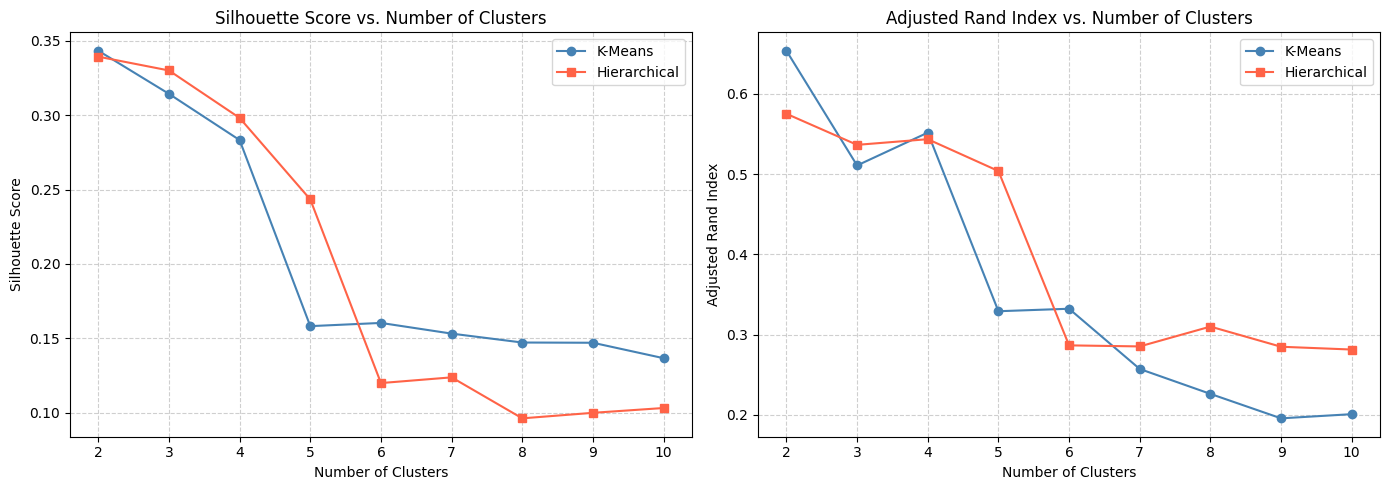

In [9]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score plot
ax1.plot(k_range, kmeans_sil, color='steelblue', marker='o', label='K-Means')
ax1.plot(k_range, hier_sil, color='tomato', marker='s', label='Hierarchical')
ax1.set_title('Silhouette Score vs. Number of Clusters')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Silhouette Score')
ax1.set_xticks(k_range)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# ARI plot
ax2.plot(k_range, kmeans_ari, color='steelblue', marker='o', label='K-Means')
ax2.plot(k_range, hier_ari, color='tomato', marker='s', label='Hierarchical')
ax2.set_title('Adjusted Rand Index vs. Number of Clusters')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Adjusted Rand Index')
ax2.set_xticks(k_range)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### StandardScaler: 
transforms all 30 features to zero mean and unit variance so that large-scale features (like Area) don't dominate the distance calculations.

#### True labels:
extracted from column 1 of your original dataframe (M/B mapped to 1/0) and used solely for computing ARI. They are not passed into the clustering algorithms.

#### KMeans:
n_init=10 runs 10 different centroid initializations and picks the best, and random_state=42 ensures reproducibility.

#### AgglomerativeClustering:
uses Ward linkage by default, which tends to produce compact, evenly-sized clusters and is a solid general-purpose choice.

#### Silhouette Score:
measures intra-cluster cohesion vs. inter-cluster separation; higher is better (max 1.0).

#### ARI:
measures how well the clustering matches the true M/B labels, corrected for chance; 1.0 = perfect match, ~0 = random.